In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import os

In [2]:
DATA_ROOT = r'depth_selection/val_selection_cropped'
IMG_DIR = os.path.join(DATA_ROOT, 'image')
DEPTH_GT_DIR = os.path.join(DATA_ROOT, 'groundtruth_depth')

In [3]:
class DepthEstimationNet(nn.Module):
    def __init__(self):
        super(DepthEstimationNet, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2]) 

        self.decoder = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(32, 40), mode='bilinear', align_corners=True),  
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(64, 80), mode='bilinear', align_corners=True), 
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(128, 160), mode='bilinear', align_corners=True), 
            nn.Conv2d(256, 1, kernel_size=1)  # Single-channel depth map
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [5]:
transform_rgb = transforms.Compose([
    transforms.Resize((228, 304)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_depth = transforms.Compose([
    transforms.Resize((128, 160)),  
    transforms.ToTensor()
])

In [10]:

class NYUDepthDataset(Dataset):
    def __init__(self, img_dir, depth_dir, transform_rgb, transform_depth, target_size=(160, 160)):
        self.img_dir = Path(img_dir)
        self.depth_dir = Path(depth_dir)
        self.transform_rgb = transform_rgb
        self.transform_depth = transform_depth
        self.image_filenames = sorted(os.listdir(img_dir))
        self.target_size = target_size

    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):

        img_name = self.image_filenames[idx]
        rgb_path = os.path.join(self.img_dir, img_name)
        depth_img_name = img_name.replace("image", "groundtruth_depth", 1)  
        depth_path = os.path.join(self.depth_dir, depth_img_name)

        if not os.path.exists(depth_path):
            raise FileNotFoundError(f"Depth file not found: {depth_path}")

        rgb = Image.open(rgb_path).convert('RGB')
        depth = Image.open(depth_path)

        rgb = rgb.resize(self.target_size)
        depth = depth.resize(self.target_size)
        rgb = self.transform_rgb(rgb)
        depth = self.transform_depth(depth)
        depth = np.array(depth).astype(np.float32)
        depth = torch.from_numpy(depth).unsqueeze(0)  

        return rgb, depth
    


In [11]:
target_size = (128, 160)

full_dataset = NYUDepthDataset(IMG_DIR, DEPTH_GT_DIR, transform_rgb, transform_depth, target_size)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DepthEstimationNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

c:\Users\athit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\athit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for i, (rgb, depth) in enumerate(train_loader):
        rgb, depth = rgb.to(device), depth.to(device)

        optimizer.zero_grad()
        outputs = model(rgb)
        #print(outputs.shape, depth.shape)
        loss = criterion(outputs, depth)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss/len(train_loader):.4f}")

C:\Users\athit\AppData\Local\Temp\ipykernel_13684\1720036572.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  depth = np.array(depth).astype(np.float32)


KeyboardInterrupt: 

In [16]:
def infer_and_visualize(rgb_tensor, pred_depth, gt_depth):
    rgb = rgb_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    rgb = (rgb * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    rgb = np.clip(rgb, 0, 1)

    pred_depth = pred_depth.squeeze().cpu().numpy()
    gt_depth = gt_depth.squeeze().cpu().numpy()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(pred_depth, cmap='inferno')
    plt.title("Predicted Depth")
    plt.axis('off')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(gt_depth, cmap='inferno')
    plt.title("Ground Truth Depth")
    plt.axis('off')
    plt.colorbar()
    plt.show()

C:\Users\athit\AppData\Local\Temp\ipykernel_13684\1720036572.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  depth = np.array(depth).astype(np.float32)


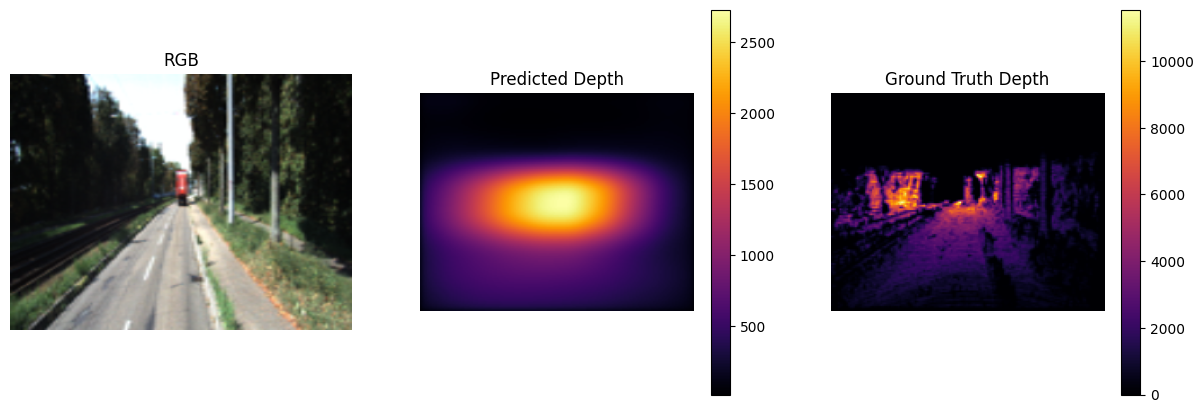

In [17]:
model.eval()
with torch.no_grad():
    sample = next(iter(test_loader))
    rgb, gt_depth = sample[0].to(device), sample[1].to(device)
    pred_depth = model(rgb)
    infer_and_visualize(rgb.cpu(), pred_depth.cpu(), gt_depth.cpu())